<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/EX2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CARLOS SANTIAGO NAVA

In [109]:
from math import sin, cos
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
from google.colab import files
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from scipy import stats

# EJERCISIO 1

In [3]:
def f(entrada):
  return ((6*entrada[0]-2)**2) * sin(12*entrada[0]-4)+((4*entrada[1]-3)**2)*cos(9*entrada[1]-1)+ ((5*entrada[2]-1)**2) * sin(8*entrada[2]-4)

In [4]:
#PUNTOS INCIALES EM RANGP[0,1]
f([0,0,0])

8.646733229352899

In [5]:
f([1,.5,.6])

17.762699622281403

In [6]:

f([1,1,1])

3.5753919872386444

In [7]:
f([1,.4,.3])

13.900336588610596

In [8]:
f([.5,.5,.5])

-0.027159260465114632

In [9]:
salida = [8.646733229352899,17.762699622281403,3.575391987238644,13.900336588610596,-0.027159260465114632]
entrada = [[0,0,0],[1,.5,.6],[1,1,1],[1,.4,.3],[.5,.5,.5]]

kernel = 1 * RBF(length_scale=1.0)

gpr = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=10)

In [10]:
#BUSQUEDA POR REDEUCCION DE INCERTIDUMBRE
for i in range(15):
  gpr.fit(entrada,salida)#ENTRENAMOS CON LO RECOPILADO
  x_pred = np.linspace(0, 1, 10000) #EL INTERVALO DE 0-1
  y_pred = np.linspace(0, 1, 10000)
  z_pred = np.linspace(0, 1, 10000)
  salida_pred_matrix = np.column_stack((x_pred, y_pred, z_pred))
  salida_pred, sigma = gpr.predict(salida_pred_matrix, return_std=True)

  indice_max_y = np.argmin(salida_pred) #Buscamos el elemento más BAJO
  nuevo_punto = salida_pred_matrix[indice_max_y]
  nuevo_el = f(nuevo_punto)

  #lo agregamos
  entrada = np.vstack([entrada, nuevo_punto])
  salida = np.append(salida, nuevo_el)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local

In [13]:
maxima_salida_loc = np.argmin(salida) #Buscamos el elemento más alto
max_salida = salida[maxima_salida_loc]
max_entrada = entrada[maxima_salida_loc]
print(maxima_salida_loc)
print(f'minimos_: {max_salida}')
print(f'combinación ganadora: {max_entrada}')

10
minimos_: -2.297195732674348
combinación ganadora: [0.39173917 0.39173917 0.39173917]


# EJERCISIO 2

El dataset adidas contiene información acerca de productos y la calificación que se les dio por usuarios. Utiliza regresión logística para conseguir un modelo que nos ayude a decidir si un producto será clasificado como bueno (average_rating>=4.3). Crea al menos 2 interacciones entre diferentes factores.

Encuentra la significancia estadística de los factores utilizados.

Cross-validation a utilizar: Train-test.

Métrico a utilizar: Accuracy. Explica el significado del score que arroje tu modelo. Analiza el resultado de los p-values encontrados.

In [24]:
dt = files.upload()

Saving adidas.csv to adidas (1).csv


In [25]:
df = pd.read_csv('adidas.csv')

In [26]:
df.head(20)

,url,name,sku,selling_price,original_price,currency,availability,color,category,source,source_website,breadcrumbs,description,brand,images,country,language,average_rating,reviews_count,crawled_at
0,https://www.adidas.com/us/beach-shorts/FJ5089....,Beach Shorts,FJ5089,40,NaN,USD,InStock,Black,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,Splashing in the surf. Making memories with yo...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.5,35,2021-10-23 17:50:17.331255
1,https://www.adidas.com/us/five-ten-kestrel-lac...,Five Ten Kestrel Lace Mountain Bike Shoes,BC0770,150,NaN,USD,InStock,Grey,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,Lace up and get after it. The Five Ten Kestrel...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,4,2021-10-23 17:50:17.423830
2,https://www.adidas.com/us/mexico-away-jersey/G...,Mexico Away Jersey,GC7946,70,NaN,USD,InStock,White,Clothing,adidas United States,https://www.adidas.com,Kids/Clothing,"Clean and crisp, this adidas Mexico Away Jerse...",adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.9,42,2021-10-23 17:50:17.530834
3,https://www.adidas.com/us/five-ten-hiangle-pro...,Five Ten Hiangle Pro Competition Climbing Shoes,FV4744,160,NaN,USD,InStock,Black,Shoes,adidas United States,https://www.adidas.com,Five Ten/Shoes,The Hiangle Pro takes on the classic shape of ...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,3.7,7,2021-10-23 17:50:17.615054
4,https://www.adidas.com/us/mesh-broken-stripe-p...,Mesh Broken-Stripe Polo Shirt,GM0239,65,NaN,USD,InStock,Blue,Clothing,adidas United States,https://www.adidas.com,Men/Clothing,Step up to the tee relaxed. This adidas golf p...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,11,2021-10-23 17:50:17.702680
5,https://www.adidas.com/us/eqt-spikeless-golf-s...,EQT Spikeless Golf Shoes,FX7449,110,NaN,USD,InStock,Grey,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,Put comfort first. These adidas spikeless golf...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.9,30,2021-10-23 17:50:17.783493
6,https://www.adidas.com/us/adicross-hybrid-shor...,Adicross Hybrid Shorts,GM5505,80,NaN,USD,InStock,Black,Clothing,adidas United States,https://www.adidas.com,Men/Clothing,"On the golf course, comfort is an essential co...",adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.5,17,2021-10-23 17:50:17.860269
7,https://www.adidas.com/us/tiro-21-windbreaker/...,Tiro 21 Windbreaker,GP4975,60,NaN,USD,InStock,Black,Clothing,adidas United States,https://www.adidas.com,Kids/Clothing,You can't always be a force of nature in socce...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.5,16,2021-10-23 17:50:17.942359
8,https://www.adidas.com/us/classic-3-stripes-sw...,Classic 3-Stripes Swimsuit,FS3923,40,NaN,USD,InStock,Black,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,You can show your concern for the health of th...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.5,35,2021-10-23 17:50:18.136849
9,https://www.adidas.com/us/tiro-21-windbreaker/...,Tiro 21 Windbreaker,GP4967,65,NaN,USD,InStock,Black,Clothing,adidas United States,https://www.adidas.com,Men/Clothing,You can't always be a force of nature in socce...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,66,2021-10-23 17:50:18.581061


In [29]:
df.drop(columns=['original_price'])

,url,name,sku,selling_price,currency,availability,color,category,source,source_website,breadcrumbs,description,brand,images,country,language,average_rating,reviews_count,crawled_at
0,https://www.adidas.com/us/beach-shorts/FJ5089....,Beach Shorts,FJ5089,40,USD,InStock,Black,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,Splashing in the surf. Making memories with yo...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.5,35,2021-10-23 17:50:17.331255
1,https://www.adidas.com/us/five-ten-kestrel-lac...,Five Ten Kestrel Lace Mountain Bike Shoes,BC0770,150,USD,InStock,Grey,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,Lace up and get after it. The Five Ten Kestrel...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,4,2021-10-23 17:50:17.423830
2,https://www.adidas.com/us/mexico-away-jersey/G...,Mexico Away Jersey,GC7946,70,USD,InStock,White,Clothing,adidas United States,https://www.adidas.com,Kids/Clothing,"Clean and crisp, this adidas Mexico Away Jerse...",adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.9,42,2021-10-23 17:50:17.530834
3,https://www.adidas.com/us/five-ten-hiangle-pro...,Five Ten Hiangle Pro Competition Climbing Shoes,FV4744,160,USD,InStock,Black,Shoes,adidas United States,https://www.adidas.com,Five Ten/Shoes,The Hiangle Pro takes on the classic shape of ...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,3.7,7,2021-10-23 17:50:17.615054
4,https://www.adidas.com/us/mesh-broken-stripe-p...,Mesh Broken-Stripe Polo Shirt,GM0239,65,USD,InStock,Blue,Clothing,adidas United States,https://www.adidas.com,Men/Clothing,Step up to the tee relaxed. This adidas golf p...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,11,2021-10-23 17:50:17.702680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,https://www.adidas.com/us/supernova-plus-shoes...,Supernova+ Shoes,FX2858,72,USD,InStock,White,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,Take off. Touch down. Repeat. These adidas run...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.3,151,2021-10-23 17:52:31.937924
841,https://www.adidas.com/us/choigo-shoes/H00667....,Choigo Shoes,H00667,70,USD,InStock,White,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,"If you want drama, the bold female track and f...",adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,135,2021-10-23 17:52:32.014973
842,https://www.adidas.com/us/daily-3.0-shoes/GZ77...,Daily 3.0 Shoes,GZ7705,35,USD,InStock,Black,Shoes,adidas United States,https://www.adidas.com,Kids/Shoes,The style is in the details of the Daily 3.0 S...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,190,2021-10-23 17:52:32.208426
843,https://www.adidas.com/us/daily-3.0-shoes/GZ77...,Daily 3.0 Shoes,GZ7706,40,USD,InStock,Pink,Shoes,adidas United States,https://www.adidas.com,Kids/Shoes,The style is in the details of the Daily 3.0 S...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,190,2021-10-23 17:52:32.293622


In [30]:
df.dropna()

,url,name,sku,selling_price,original_price,currency,availability,color,category,source,source_website,breadcrumbs,description,brand,images,country,language,average_rating,reviews_count,crawled_at
15,https://www.adidas.com/us/essentials-loose-log...,Essentials Loose Logo Tank Top,H07758,20,$25,USD,InStock,Purple,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,What's on the agenda? Whether it's a quick lun...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,116,2021-10-23 17:50:19.626607
16,https://www.adidas.com/us/essentials-loose-log...,Essentials Loose Logo Tank Top,H07757,20,$25,USD,InStock,Pink,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,What's on the agenda? Whether it's a quick lun...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,116,2021-10-23 17:50:19.814818
18,https://www.adidas.com/us/essentials-loose-log...,Essentials Loose Logo Tank Top,H07756,20,$25,USD,InStock,Green,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,What's on the agenda? Whether it's a quick lun...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,116,2021-10-23 17:50:19.974618
19,https://www.adidas.com/us/formotion-sculpt-tig...,Formotion Sculpt Tights,GN9137,48,$80,USD,InStock,Blue,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,Sometimes confidence comes in a surprising for...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.2,144,2021-10-23 17:50:20.051878
20,https://www.adidas.com/us/marvel-x-ghosted.3-f...,Marvel X Ghosted.3 Firm Ground Cleats,FZ1757,64,$80,USD,InStock,Blue,Shoes,adidas United States,https://www.adidas.com,Soccer/Shoes,X has mutated to give you superhuman accelerat...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.4,160,2021-10-23 17:50:20.140542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,https://www.adidas.com/us/supernova-plus-shoes...,Supernova+ Shoes,FX2858,72,$120,USD,InStock,White,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,Take off. Touch down. Repeat. These adidas run...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.3,151,2021-10-23 17:52:31.937924
841,https://www.adidas.com/us/choigo-shoes/H00667....,Choigo Shoes,H00667,70,$100,USD,InStock,White,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,"If you want drama, the bold female track and f...",adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,135,2021-10-23 17:52:32.014973
842,https://www.adidas.com/us/daily-3.0-shoes/GZ77...,Daily 3.0 Shoes,GZ7705,35,$50,USD,InStock,Black,Shoes,adidas United States,https://www.adidas.com,Kids/Shoes,The style is in the details of the Daily 3.0 S...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,190,2021-10-23 17:52:32.208426
843,https://www.adidas.com/us/daily-3.0-shoes/GZ77...,Daily 3.0 Shoes,GZ7706,40,$50,USD,InStock,Pink,Shoes,adidas United States,https://www.adidas.com,Kids/Shoes,The style is in the details of the Daily 3.0 S...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,190,2021-10-23 17:52:32.293622


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             845 non-null    object 
 1   name            845 non-null    object 
 2   sku             845 non-null    object 
 3   selling_price   845 non-null    int64  
 4   original_price  829 non-null    object 
 5   currency        845 non-null    object 
 6   availability    845 non-null    object 
 7   color           845 non-null    object 
 8   category        845 non-null    object 
 9   source          845 non-null    object 
 10  source_website  845 non-null    object 
 11  breadcrumbs     845 non-null    object 
 12  description     845 non-null    object 
 13  brand           845 non-null    object 
 14  images          845 non-null    object 
 15  country         845 non-null    object 
 16  language        845 non-null    object 
 17  average_rating  845 non-null    flo

In [32]:
#APLICAMOS BINARIOS
umbral = 4.3
df['average_rating'] = (df['average_rating'] >= umbral).astype(int)

array([[<Axes: title={'center': 'selling_price'}>,
        <Axes: title={'center': 'average_rating'}>],
       [<Axes: title={'center': 'reviews_count'}>, <Axes: >]],
      dtype=object)

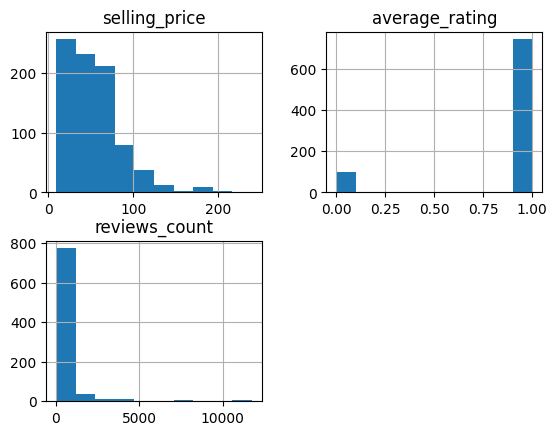

In [33]:
df.hist()

MUCHOS MÁS 1 QUE 0, considero qye selling price esta sesgado



In [116]:
categorical_columns = ['name','currency','availability','color','category','source','country', 'breadcrumbs','brand','language']
for i in categorical_columns:
  df[i] = df[i].astype('category')


In [117]:
df['interacción1'] = df['selling_price'] * df['reviews_count']
df['interacción2'] = df['selling_price'] * df['selling_price']

ESTABLESCO MODELO Y PIPELINE

In [118]:
x_test, x_train, y_test, y_train = train_test_split(df, df['average_rating'], test_size=0.2, random_state=42)


In [119]:
df.head(1)

,url,name,sku,selling_price,original_price,currency,availability,color,category,source,...,description,brand,images,country,language,average_rating,reviews_count,crawled_at,interacción1,interacción2
0,https://www.adidas.com/us/beach-shorts/FJ5089....,Beach Shorts,FJ5089,40,NaN,USD,InStock,Black,Clothing,adidas United States,...,Splashing in the surf. Making memories with yo...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,1,35,2021-10-23 17:50:17.331255,1400,1600


In [120]:
numerical_columns = ['selling_price','interacción1','interacción2']
categorical_columns = ['name','currency','availability','color','category','source','country', 'breadcrumbs','brand','language']
target_col = ['average_rating']

In [121]:
X = df[numerical_columns + categorical_columns]
y = df[target_col].values.ravel()

In [122]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')
model = LogisticRegression()

In [123]:
preprocesor = ColumnTransformer(transformers=[('num',num_transformer,numerical_columns), ('cat', cat_transformer, categorical_columns)])
pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', model)])

In [124]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['selling_price',
                                                   'interacción1',
                                                   'interacción2']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name', 'currency',
                                                   'availability', 'color',
                                                   'category', 'source',
                                                   'country', 'breadcrumbs',
                                                   'brand', 'language'])])),
                ('model', LogisticRegression())])

In [125]:
scores = cross_val_score(pipeline, x_train, y_train, cv=10, scoring='accuracy')
scores.mean()

np.float64(0.8698529411764706)

In [126]:
preprocesor.fit_transform(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2197 stored elements and shape (169, 176)>

In [127]:
scores_2 = cross_val_score(pipeline, x_test, y_test, cv=10, scoring='accuracy')
scores_2.mean()

np.float64(0.9157155399473222)

## ***VALIDACIÓN ESTADÍSTICA***

In [128]:
model = pipeline.named_steps['model']


In [132]:
x_train_transformed = preprocesor.transform(x_train)

probas = model.predict_proba(x_train_transformed)[:, 1]
#regresión logística, la varianza de cada observación es p * (1 - p)
W = np.diag(probas * (1 - probas))

#Preparar la matriz de diseño z
n = x_train_transformed.shape[0]

# Ensure X_design is a dense array for matrix multiplication if sparse
if hasattr(x_train_transformed, 'toarray'):
    X_design = np.column_stack((np.ones(n), x_train_transformed.toarray()))
else:
    X_design = np.column_stack((np.ones(n), x_train_transformed))
X_design = X_design.astype(float)

# Inversa de la Matriz de Fisher: (X^T * W * X)^-1
fisher_info = X_design.T @ W @ X_design
cov_beta = np.linalg.inv(fisher_info + np.eye(X_design.shape[1]) * 1e-6) #EVITAR SINGULARIDAD

# Calcular los Errores Estándar
std_error = np.sqrt(np.diag(cov_beta))

#Extraer los betas (coeficientes)
b_0 = np.ravel(model.intercept_)
b_i = np.ravel(model.coef_)
betas = np.concatenate((b_0, b_i))

# alcular el Estadístico Z (Wald Z-statistic) debido a que tranbajamos una regresión logítica
z_stats = betas / std_error

p_values = [2 * (1 - stats.norm.cdf(np.abs(z))) for z in z_stats]

feature_names_out = preprocesor.get_feature_names_out()
all_feature_names_for_print = ['Intercepto'] + list(feature_names_out)

for i, p_val in enumerate(p_values):
    name = all_feature_names_for_print[i] if i < len(all_feature_names_for_print) else f"Variable {i}"
    print(f"{name}:  P-value = {p_val:.4e}")

Intercepto:  P-value = 9.9756e-01
num__selling_price:  P-value = 9.9173e-01
num__interacción1:  P-value = 9.2606e-01
num__interacción2:  P-value = 9.9876e-01
cat__name_4D Fusio Shoes:  P-value = 9.9507e-01
cat__name_AEROREADY  Designed to Move Sport Camo-Print Shorts:  P-value = 9.9974e-01
cat__name_AEROREADY Breathable 3-Stripes Long Sleeve Tee:  P-value = 9.9970e-01
cat__name_AEROREADY Designed 2 Move Feelready Sport Tee:  P-value = 9.9937e-01
cat__name_AEROREADY Designed 2 Move Sport Tank Top (Maternity):  P-value = 9.9936e-01
cat__name_AEROREADY Designed to Move Sport Motion Logo Tee:  P-value = 9.9973e-01
cat__name_AEROREADY FeelBrilliant Designed 2 Move 7/8 Tights (Plus Size):  P-value = 9.9658e-01
cat__name_Adicolor Branded Webbing Waist Bag:  P-value = 9.9991e-01
cat__name_Adicolor Classics Collegiate Tight Tee:  P-value = 9.9952e-01
cat__name_Adicolor Classics Crop Hoodie:  P-value = 9.9987e-01
cat__name_Adicolor Classics Long Sleeve Tee:  P-value = 9.9960e-01
cat__name_Adicol

# EJERCISIO 3

Utiliza el modelo de tu elección, con los hiperparámetros y factores de tu elección para obtener el mejor predictor que puedas conseguir para decidir si un paciente del dataset padece diabetes.

Cross-validation a utilizar: Separar en train-test, aplicar k-folds a train con métrico F1. Compara el promedio del CV con el F1 medido sobre test.

¿Está generalizando el modelo?

In [134]:
dt_2 = files.upload()

Saving diabetes.csv to diabetes.csv


In [135]:
df = pd.read_csv('diabetes.csv')

In [136]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [138]:
df.dropna()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

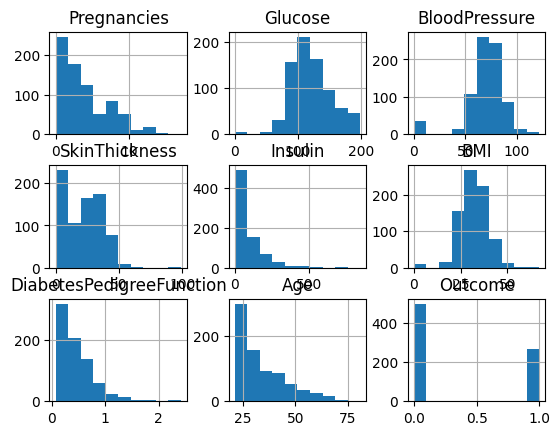

In [139]:
df.hist()


In [140]:
df.head(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1


In [141]:
numericos = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target = ['Outcome']


In [145]:
x_train, x_test, y_train, y_test = train_test_split(df, df[target], test_size=0.2, random_state=42)

In [146]:
X = df[numericos]
y = df[target].values.ravel()

In [147]:
escalador = StandardScaler()
model = SVC(kernel='rbf')

In [152]:
preprocesor = ColumnTransformer(transformers=[('num',escalador,numericos)])
pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', model)])

In [154]:
pipeline.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('model', SVC())])

In [161]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.0 MB/s eta 0:00:00


In [167]:
from skopt import BayesSearchCV
from skopt.space import Real

# Define the parameter space for C
param_distributions = {
    'model__C': Real(.001, 1000, prior='log-uniform')
}

# Instantiate BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=pipeline,
    search_spaces=param_distributions,
    n_iter=50,
    cv=10,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

bayes_search.fit(x_train , y_train.values.ravel())

print(f"Best parameters found: {bayes_search.best_params_}")
print(f"Best score found: {bayes_search.best_score_}")

Best parameters found: OrderedDict({'model__C': 4.030359292786562})
Best score found: 0.6369241096345739


In [169]:
from sklearn.metrics import f1_score
y_pred_test = bayes_search.best_estimator_.predict(x_test)
score_test = f1_score(y_test, y_pred_test)

print(score_test)

0.6037735849056604
